# **Лекция 9. Использование type hints в Python. Рекурсивные функции**

## **$\S 1.$ Использование type hits в Python**

**Type Hints** (подсказки типов) — это официальный способ указать ожидаемый тип переменных, аргументов функций и возвращаемых значений. Они были официально представлены в Python 3.5.

Идея появлялась постепенно и не сразу была принята сообществом.

2006 г. В Python 3.0 появились функциональные аннотации (Function Annotations). Синтаксически они выглядели как современные подсказки типов (def foo(a: str) -> int), но на тот момент не имели стандартизированного значения и игнорировались интерпретатором. Это был просто синтаксис для метаданных.

2013-2014 г. — Новая жизнь: Проект mypy (автор — Jukka Lehtosalo) произвел впечатление на создателя Python Гвидо ван Россума. Вдохновившись этим, Гвидо предложил использовать подобный синтаксис для стандартизации аннотаций типов.

2015 г. — В Python 3.5 типы становятся официальной функцией языка. Появляется стандартный модуль typing, содержащий такие типы, как List, Dict, Optional, Union. Сами подсказки типов на выполнение программы не влияют, но используются сторонними инструментами (mypy, Pyright, Pyre) и IDE для статического анализа.

**Главные преимущества использования Type Hints**

- Улучшенная читаемость и самодокументируемость кода: Глядя на объявление функции, сразу понятно, что в нее можно передавать, а что ожидать на выходе.

- Раннее обнаружение ошибок: Статические анализаторы вроде mypy могут найти несоответствие типов до запуска программы, отлавливая целые классы багов.

- Лучшая поддержка в IDE: Автодополнение, подсветка ошибок, рефакторинг и навигация по коду работают на порядок лучше, когда типы известны.

**Важное замечание**

**Type Hints** — это не статическая типизация в стиле Java или C++. Они полностью игнорируются интерпретатором Python во время выполнения.

Рассмотрим несколько примеров:

In [8]:
# Аннотации переменных (Python 3.6+)
name: str = "Alice"
age: int = 30
height: float = 175.5
is_active: bool = True
tags: list = []  # список без указания типа элементов
my_transaction: list[int] = [] # список с  указанием типа элементов

In [15]:
# Функции с аннотациями
def hello(name: str) -> str:
    """Возвращает приветствие"""
    return f"Привет, {name}"

In [16]:
hello('Вася')

'Привет, Вася'

In [17]:
hello(6)

'Привет, 6'

In [21]:
def add(a: int, b: int) -> int:
    return a + b

def divide(a: int, b: int) -> float:
    return a / b

In [22]:
add(8,5)

13

In [23]:
add(7.7,8.0)

15.7

In [19]:
divide(7,9)

0.7777777777777778

In [20]:
divide(7.7,3.14)

2.4522292993630574

In [24]:
# Словарь: ключи - str, значения - int
scores: dict[str, int] = {"Alice": 100, "Bob": 95, "Charlie": 87}

# Словарь: ключи - int, значения - str
users: dict[int, str] = {1: "Alice", 2: "Bob", 3: "Charlie"}

# Словарь: ключи - str, значения - list[int]
grades: dict[str, list[int]] = {
    "Alice": [5, 4, 5, 5],
    "Bob": [4, 4, 3, 5],
    "Charlie": [5, 5, 4, 4]
}

## **$\S 2.$ Рекурсивные функции**

**Рекурсия** — это когда функция вызывает саму себя для решения подзадачи того же типа.

Многие задачи, которые решаются с использованием циклов, легко переформулировать в решение рекурсией. Например,
в задаче нахождения суммы чисел от 1 до N:

$$S(N) = 1+2+3+4+\ldots+N$$

Конечно, ее можно решить так:

In [27]:
def sum(N:int) -> int:
    S = 0
    for i in range(1,N+1):
        S += i
    return S

In [29]:
sum(100)

5050

Но попробуем определить $S(N)$ саму через себя:
$$S(N) = S(N-1)+N$$
При этом мы знаем, что $S(1)=1$.

Запишем это в виде определения на Python:

In [32]:
def sum_rec(N):
    if N == 1:
        return 1
    else:
        return sum_rec(N - 1) + N

И, о чудо, это работает:

In [33]:
sum_rec(100)

5050

В рекурсии выделяют две составляющие:
- **база рекурсии** - это ситуация, когда для вычисления значения функции рекурсия не нужна. Как правило, это некоторые тривиальные случаи входных параметров (иногда баз рекурсии может быть несколько). В нашем примере база рекурсии $S(1)=1$.
- **Шаг рекурсии** - это выражение функции через саму себя. В нашем примере это $S(N)=S(N-1)+N$.

Рассмотрим еще ряд показательных примеров.

In [34]:
#Найти длину списка
def len_list(L):
    if L == []:
        return 0
    else:
        return 1 + len_list(L[1:])

In [35]:
len_list([1,2,4,6])

4

In [40]:
#Вычисление факториала
def factorial(n: int) -> int:
    # Базовый случай
    if n <= 1:
        return 1
    # Рекурсивный случай
    return n * factorial(n - 1)

In [41]:
factorial(5)

120

In [ ]:
"""
Как это работает:

actorial(5)
├── 5 * factorial(4)
    ├── 4 * factorial(3)
        ├── 3 * factorial(2)
            ├── 2 * factorial(1)
                ├── 1 (базовый случай)
            ├── 2 * 1 = 2
        ├── 3 * 2 = 6
    ├── 4 * 6 = 24
└── 5 * 24 = 120
"""

In [37]:
#Числа Фибоначчи
def fib(N):
    if N == 1:
        return 1
    elif N == 2:
        return 1
    else:
        return fib(N - 1) +fib(N - 2)    

In [39]:
fib(7)

13

**Задача о Ханойских башнях**

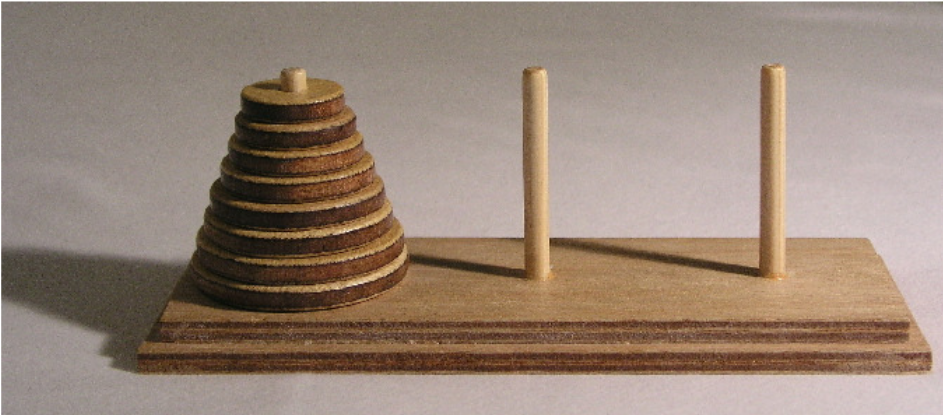

Перенести пирамиду из восьми колец. За один раз разрешается переносить только одно кольцо, причём нельзя класть большее кольцо на меньшее.

Предположим, что мы уже научились перекладывать n-1 колец, тогда алгоритм перекладывания n колец такой:
- перекладываем на средний колышек n-1 колец 
- перекладываем на крайний правый колышек самое большо кольцо
- перекладываем на крайний правый колышек n-1 колец
- Последовательно уменьшая n мы приходим к одному кольцу, алгоритм перекладывания которого очевиден. После чего легко восстанавливается весь алгоритм.

In [25]:
def hanoi(n: int, source: str, target: str, auxiliary: str) -> None:
    """Перемещает n дисков с source на target через auxiliary"""
    if n == 1:
        print(f"Переместить диск 1 с {source} на {target}")
        return
    
    hanoi(n - 1, source, auxiliary, target)
    print(f"Переместить диск {n} с {source} на {target}")
    hanoi(n - 1, auxiliary, target, source)

print("Решение для 3 дисков:")
hanoi(3, "A", "C", "B")
# Вывод покажет все 7 перемещений

Решение для 3 дисков:
Переместить диск 1 с A на C
Переместить диск 2 с A на B
Переместить диск 1 с C на B
Переместить диск 3 с A на C
Переместить диск 1 с B на A
Переместить диск 2 с B на C
Переместить диск 1 с A на C


## **$\S 3.$ Задачи на рекурсию для разбора**

1. Построить функцию, находящую минимальный элемент списка.
2. Реализовать функцию, которая возвращает первый элемент, входящий в оба списка.
3. Построить функцию, которая разбивает список на уровни, например, имеем (a b c), получаем (((a) b) c).
4. Реализовать функцию, удаляющую из списка все четные элементы.
5. Создайте функцию SUBSTITUE - заменяет все вхождения данного элемента в списке
на новый элемент
6. Создайте функцию, удаляющую из списка отрицательные числа.
7. Создайте функцию DelThree - удаляет из списка каждый третий элемент
8. Создайте функцию, удаляющую элемент на заданном месте в списке
9. Создайте функцию DIFLIST - вычисляет разность множеств X\Y (исключает из
списка, заданного в качестве значения первого аргумента функции все элементы,
встречающиеся в списке, представленном значением второго аргумента).
10. Создайте функцию, вычисляющую симметрическую разность двух множеств.
11. Функция DEPTH - вычисляет глубину списка (самой глубокой ветви).
12. Создайте функцию, вычисляющую объединение множеств.
13. Создайте функцию, осуществляющую удаление указанного количества последних
элементов исходного списка.
14. Создайте функцию, находящую третий с конца элемент списка.
15. Создайте функцию, добавляющую элементы одного списка во второй список, начиная
с заданной позиции.
16. Создайте предикат, возвращающий по списку и двум числам M и N подсписок
исходного списка, состоящий из элементов с номерами от M до N.
17. Создайте функцию, преобразующую произвольное алгебраическое выражение из
инфиксной формы записи в префиксную.